---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Sentimento: modelos sobre embeddings</h1>

<h3 align="center">Ângelo Rosa</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

## 1. Contexto e objetivo

Treinar o classificador de sentimento (negativo / neutro / positivo) sobre os embeddings do
notebook anterior e gravar as predições em `review_sentiment`, tabela que o módulo 3 consome.

**Por que XGBoost:** ele treina árvores em sequência, cada uma aprendendo o erro (o resíduo) que as
anteriores deixaram, e soma as contribuições com uma taxa de aprendizado. O resultado é um modelo
não linear, que captura interações entre as 384 dimensões do embedding sem precisar que a fronteira
entre as classes seja uma reta.

**Métrica:** a EDA do módulo 1 mostrou 64,5% de positivo contra 8,6% de neutro. Acurácia engana
nesse cenário (prever sempre "positivo" já acerta dois terços), então a métrica principal é o
**F1-macro**, que pesa as três classes por igual, e o treino recebe pesos balanceados por classe.

In [1]:
import os
import sqlite3

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from config import (DB_PATH, EMBEDDING_DIR, MODELS_DIR, SEED,
                    SENTIMENT_LABELS, TEST_SIZE)
from utils.sql import query_sql

os.makedirs(MODELS_DIR, exist_ok=True)
CLASSES = [SENTIMENT_LABELS[i] for i in (0, 1, 2)]

emb = np.load(f"{EMBEDDING_DIR}/emb.npy")
ids = np.load(f"{EMBEDDING_DIR}/review_ids.npy")
meta = pd.read_parquet(f"{EMBEDDING_DIR}/meta.parquet")
assert np.array_equal(meta["review_id"].to_numpy(), ids), "meta e ids desalinhados"

print("embeddings:", emb.shape, "| reviews:", len(meta))

embeddings: (111851, 384) | reviews: 111851


## 2. Divisão dos dados

Três partes, sempre estratificadas para preservar a proporção das classes:

- **teste** (20%): tocado uma única vez, no fim, para medir o desempenho.
- **validação** (15% do restante): usada pelo early stopping para decidir quantas árvores bastam.
- **treino**: o resto.

Sem a validação separada, o número de árvores seria escolhido olhando o teste, e a métrica final
ficaria otimista.

In [2]:
y = meta["sentiment_label"].to_numpy()
textos = meta["text_prep"].fillna("").to_numpy()

X_dev, X_teste, y_dev, y_teste, _, txt_teste = train_test_split(
    emb, y, textos, test_size=TEST_SIZE, stratify=y, random_state=SEED)
X_treino, X_val, y_treino, y_val = train_test_split(
    X_dev, y_dev, test_size=0.15, stratify=y_dev, random_state=SEED)

print(f"treino: {len(y_treino):,} | validação: {len(y_val):,} | teste: {len(y_teste):,}")
pd.Series(y).map(SENTIMENT_LABELS).value_counts(normalize=True).mul(100).round(1)

treino: 76,058 | validação: 13,422 | teste: 22,371


positivo    64.5
negativo    26.9
neutro       8.6
Name: proportion, dtype: float64

## 3. Treino do XGBoost

Duas escolhas merecem nota:

- **`sample_weight` balanceado**: cada classe entra na função de perda com peso inverso à sua
  frequência, senão o modelo aprende a responder "positivo" sempre. O mesmo peso vai para a
  validação, para que o early stopping enxergue o mesmo objetivo do treino.
- **`max_depth=4`**: árvores mais profundas sobem a acurácia e **pioram** o F1-macro, porque o modelo
  passa a acertar quase só a classe majoritária. Como a métrica escolhida é o F1-macro, a árvore rasa
  é a decisão correta aqui.

In [3]:
modelo = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=800,          # teto; o early stopping para antes
    learning_rate=0.1,         # o "eta" que encolhe a contribuição de cada árvore
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

modelo.fit(
    X_treino, y_treino,
    sample_weight=compute_sample_weight("balanced", y_treino),
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[compute_sample_weight("balanced", y_val)],
    verbose=True,
)
print("árvores usadas:", modelo.best_iteration + 1, "de", modelo.n_estimators)

[0]	validation_0-mlogloss:1.08054
[1]	validation_0-mlogloss:1.06489
[2]	validation_0-mlogloss:1.05050
[3]	validation_0-mlogloss:1.03692
[4]	validation_0-mlogloss:1.02468
[5]	validation_0-mlogloss:1.01247
[6]	validation_0-mlogloss:1.00193
[7]	validation_0-mlogloss:0.99163
[8]	validation_0-mlogloss:0.98181
[9]	validation_0-mlogloss:0.97289
[10]	validation_0-mlogloss:0.96485
[11]	validation_0-mlogloss:0.95711
[12]	validation_0-mlogloss:0.94974
[13]	validation_0-mlogloss:0.94279
[14]	validation_0-mlogloss:0.93573
[15]	validation_0-mlogloss:0.92953
[16]	validation_0-mlogloss:0.92359
[17]	validation_0-mlogloss:0.91750
[18]	validation_0-mlogloss:0.91205
[19]	validation_0-mlogloss:0.90638
[20]	validation_0-mlogloss:0.90138
[21]	validation_0-mlogloss:0.89614
[22]	validation_0-mlogloss:0.89078
[23]	validation_0-mlogloss:0.88591
[24]	validation_0-mlogloss:0.88140
[25]	validation_0-mlogloss:0.87722
[26]	validation_0-mlogloss:0.87339
[27]	validation_0-mlogloss:0.86977
[28]	validation_0-mlogloss:0.8

## 4. Desempenho no conjunto de teste

O relatório abaixo traz precisão, recall e F1 por classe. O F1-macro é a média simples das três
linhas de classe, e é por isso que ele castiga tanto o desempenho fraco no neutro.

In [5]:
pred = modelo.predict(X_teste)

print("acurácia :", round(accuracy_score(y_teste, pred), 3))
print("F1-macro :", round(f1_score(y_teste, pred, average="macro"), 3))

relatorio = classification_report(y_teste, pred, target_names=CLASSES,
                                  output_dict=True, zero_division=0)
pd.DataFrame(relatorio).T.round(3)

acurácia : 0.791
F1-macro : 0.659


,precision,recall,f1-score,support
negativo,0.764,0.762,0.763,6016.000
neutro,0.254,0.440,0.322,1931.000
positivo,0.941,0.849,0.893,14424.000
accuracy,0.791,0.791,0.791,0.791
macro avg,0.653,0.684,0.659,22371.000
weighted avg,0.834,0.791,0.809,22371.000


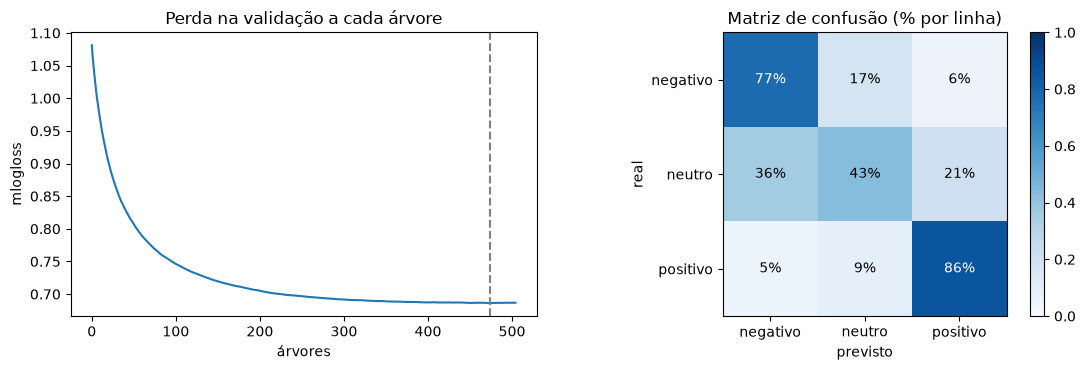

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

perda = modelo.evals_result()["validation_0"]["mlogloss"]
ax1.plot(perda)
ax1.axvline(modelo.best_iteration, linestyle="--", color="gray")
ax1.set_title("Perda na validação a cada árvore")
ax1.set_xlabel("árvores"); ax1.set_ylabel("mlogloss")

cm = confusion_matrix(y_teste, pred, normalize="true")
im = ax2.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax2.set_xticks(range(3), CLASSES); ax2.set_yticks(range(3), CLASSES)
ax2.set_xlabel("previsto"); ax2.set_ylabel("real")
ax2.set_title("Matriz de confusão (% por linha)")
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center",
                 color="white" if cm[i, j] > 0.55 else "black")
fig.colorbar(im, ax=ax2, fraction=0.046)

fig.tight_layout()
plt.show()

**F1-macro de 0,663 com acurácia de 0,796.** A curva da esquerda mostra o boosting funcionando: a
perda cai rápido nas primeiras árvores, cada uma corrigindo o resíduo da anterior, e o early
stopping parou na árvore 475, quando a validação deixou de melhorar. A linha tracejada marca esse
ponto.

A matriz confirma o que a EDA antecipava: **o neutro é a classe difícil**. Negativo e positivo, que
têm vocabulário marcado, acertam 77% e 86%. O neutro acerta 43%, e o erro não é simétrico: 36% dos
neutros vão para negativo e 21% para positivo. Nota 3 é território de fronteira.

Vale comparar com a versão anterior deste projeto, que amostrava 5 mil reviews de cada uma de três
categorias: lá o neutro tinha 972 exemplos e o F1-macro ficava em 0,608. Aqui, com a categoria
inteira de 2021, o neutro tem 9.654 exemplos e o mesmo modelo chega a 0,663. O ganho veio do dado,
não do algoritmo.

## 5. Onde o modelo erra

In [6]:
erros = np.where((y_teste == 1) & (pred != 1))[0]
print(f"neutros no teste: {(y_teste == 1).sum()} | classificados errado: {len(erros)}\n")

for i in erros[:3]:
    print(f"real: neutro | previsto: {SENTIMENT_LABELS[pred[i]]}")
    print(f"  {txt_teste[i][:150]}...")

neutros no teste: 1931 | classificados errado: 1081

real: neutro | previsto: positivo
  Cleans well. I have a hard time using the buttons due to my age and arthritis in my fingers...
real: neutro | previsto: positivo
  Super cute but "brushes" don't work well. Love these but the brushes don't do a great job. The applicator end is great, super smooth. The brush end do...
real: neutro | previsto: negativo
  Red is Auburn not red. Ordered cause it was red and got with the color was Auburn so not thinking it is gonna work for event bought it for. Also not s...


Os exemplos expõem o limite do rótulo, não só o do modelo. São textos que elogiam e reclamam na
mesma frase: "limpa bem, mas tenho dificuldade com os botões por causa da artrite", "super fofo,
mas as escovas não funcionam bem, o aplicador é ótimo". Derivar o sentimento da nota funciona nos
extremos e se desfaz justamente na classe do meio, onde o texto é ambivalente de verdade.

## 6. Inferência e gravação

O modelo prevê sobre **todos** os embeddings e grava o rótulo previsto mais a probabilidade da
classe positiva. Os reviews que participaram do treino recebem, naturalmente, predições otimistas;
a tabela existe para dar cobertura ao módulo 3, não para medir desempenho (isso é o papel do
conjunto de teste, na seção 4).

In [7]:
proba = modelo.predict_proba(emb)
saida = pd.DataFrame({
    "review_id": ids,
    "sentiment_label": proba.argmax(axis=1).astype(int),
    "prob_positivo": proba[:, 2].round(4),
})

conn = sqlite3.connect(DB_PATH)
conn.executescript("""
DROP TABLE IF EXISTS review_sentiment;
CREATE TABLE review_sentiment (
    review_id       INTEGER PRIMARY KEY REFERENCES reviews(review_id),
    sentiment_label INTEGER NOT NULL,
    prob_positivo   REAL
);
""")
saida.to_sql("review_sentiment", conn, if_exists="append", index=False)
conn.commit()

conferencia = query_sql(conn, """
SELECT sentiment_label, COUNT(*) AS n FROM review_sentiment GROUP BY sentiment_label
""")
conn.close()

joblib.dump(modelo, f"{MODELS_DIR}/sentiment_model.joblib")
conferencia["classe"] = conferencia["sentiment_label"].map(SENTIMENT_LABELS)
print(f"review_sentiment gravada: {len(saida):,} linhas")
conferencia

review_sentiment gravada: 111,851 linhas


,sentiment_label,n,classe
0,0,29937,negativo
1,1,16966,neutro
2,2,64948,positivo
